# [Step 6 - Strategy Comparison] Picking the right cutter

**MLCourse - Agentic AI - Module 06: Chunking Strategies**

> Stage in the capstone: stage 2 CHUNK: chunk quality decides retrieval accuracy in the capstone.

## What you'll learn

- all five strategies run on the SAME slice under the SAME metrics
- a pandas scoreboard: chunk counts, size spread, mid-sentence cut rate
- reading trade-offs off one chart instead of folklore
- the decision-guide recap that routes any document to its splitter

---

In [1]:
# =====================================================================
# CELL 1 - SHARED SETUP: imports, track discovery, download-once cache
# =====================================================================

# --- Standard library -------------------------------------------------
import os                      # file-system odds and ends
import statistics              # standard deviation for size spread
import urllib.request          # polite HTTP fetching
from pathlib import Path       # object-oriented filesystem paths

# --- Lesson-specific imports ------------------------------------------
import matplotlib.pyplot as plt                                  # bar charts
import pandas as pd                                              # the scoreboard
from langchain_community.document_loaders import TextLoader      # alice source
from langchain_text_splitters import (
    CharacterTextSplitter,
    RecursiveCharacterTextSplitter,
    TokenTextSplitter,
    MarkdownHeaderTextSplitter,
    Language,
)

# ---------------------------------------------------------------------
# TRACK WALKER - resolve 03_agentic_ai by walking upward from cwd.
# ---------------------------------------------------------------------
def _find_track(start: Path) -> Path:
    """Return the absolute path of the 03_agentic_ai track root."""
    for candidate in (start, *start.parents):
        hit = candidate / "03_agentic_ai"
        if hit.is_dir():
            return hit.resolve()
    raise FileNotFoundError(
        f"No directory named 03_agentic_ai found above {start} - "
        "run this notebook from somewhere inside the MLCourse repo."
    )

TRACK = _find_track(Path.cwd())
DATA = TRACK / "data"
DATA.mkdir(parents=True, exist_ok=True)

# ---------------------------------------------------------------------
# DOWNLOAD-ONCE HELPERS - fetch once, cache under DATA, reuse forever.
# ---------------------------------------------------------------------
def get_bytes(fname: str, url: str) -> bytes:
    """Return the file's bytes, downloading only on the very first call."""
    target = DATA / fname
    if target.exists() and target.stat().st_size > 0:
        payload = target.read_bytes()
        print(f"[cache] {fname}: {len(payload):,} bytes")
        return payload
    print(f"[fetch] {url}")
    request = urllib.request.Request(url, headers={"User-Agent": "MLCourse/1.0"})
    with urllib.request.urlopen(request, timeout=60) as response:
        payload = response.read()
    target.write_bytes(payload)
    print(f"[saved] {fname}: {len(payload):,} bytes")
    return payload

try:
    get_ipython().run_line_magic("matplotlib", "inline")
except Exception:
    pass

# =====================================================================
# ANALYSIS TOOLBOX - identical across chunking notebooks.
# =====================================================================
_CURLY = {"\u2019": "'", "\u201d": '"', "\u201c": '"', "\u2018": "'"}
SENTENCE_ENDS = tuple(".!?\"')")

def ends_naturally(chunk: str) -> bool:
    """Heuristic: a CLEAN chunk tail ends in sentence-final punctuation."""
    tail = chunk.rstrip()
    if not tail:
        return True
    tail = "".join(_CURLY.get(ch, ch) for ch in tail[-3:])
    return tail.endswith(SENTENCE_ENDS)

def cut_pct(chunks):
    """Percent of chunks NOT ending in terminal punctuation."""
    bad = sum(1 for c in chunks if not ends_naturally(c))
    return 100.0 * bad / max(len(chunks), 1)

C:\Users\Thoyajaksha Kashyap\AppData\Local\Temp\ipykernel_6568\3682909165.py:14: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.document_loaders import TextLoader      # alice source


## 1. The protocol: fair fight, honest metrics

**Same input**: `text[:20000]` of Alice (the full novel would drown the
degenerate rows in noise; 20k chars is enough structure to judge).

**Same metrics** for every strategy:

| metric | meaning |
|---|---|
| `n_chunks` | how many retrieval units were produced |
| `mean_chars` / `std_chars` | average size and spread (low std = predictable budgets) |
| `pct_cut_mid_sentence` | share of chunks NOT ending in punctuation (lower = kinder boundaries) |

**Contestants**: character, recursive, token, markdown-header, code-aware -
notebooks 01 through 05, one arena.

In [2]:
get_bytes("alice.txt", "https://www.gutenberg.org/files/11/11-0.txt")
alice_docs = TextLoader(str(DATA / "alice.txt"), encoding="utf-8").load()
text = alice_docs[0].page_content
SLICE = text[:20000]
print(f"arena : {len(SLICE):,} characters of Alice")

md_header_splitter = MarkdownHeaderTextSplitter(
    headers_to_split_on=[("#", "H1"), ("##", "H2"), ("###", "H3")])

STRATEGIES = [
    ("character (\\n\\n)", lambda t: CharacterTextSplitter(
        separator="\n\n", chunk_size=500, chunk_overlap=100).split_text(t)),
    ("recursive", lambda t: RecursiveCharacterTextSplitter(
        chunk_size=500, chunk_overlap=100).split_text(t)),
    ("token (256t/32t)", lambda t: TokenTextSplitter(
        encoding_name="cl100k_base", chunk_size=256, chunk_overlap=32).split_text(t)),
    ("markdown-header", lambda t: [d.page_content
                                   for d in md_header_splitter.split_text(t)]),
    ("code-aware PYTHON", lambda t: RecursiveCharacterTextSplitter.from_language(
        Language.PYTHON, chunk_size=500, chunk_overlap=100).split_text(t)),
]

rows = []
for name, runner in STRATEGIES:
    chunks = runner(SLICE)
    sizes = [len(c) for c in chunks]
    rows.append({
        "strategy": name,
        "n_chunks": len(chunks),
        "mean_chars": round(sum(sizes) / max(len(sizes), 1), 1),
        "std_chars": round(statistics.stdev(sizes) if len(sizes) > 1 else 0.0, 1),
        "pct_cut_mid_sentence": round(cut_pct(chunks), 1),
    })

df = pd.DataFrame(rows)
print("\n=== SCOREBOARD (alice[:20000]) ===")
print(df.to_string(index=False))

Created a chunk of size 739, which is longer than the specified 500


Created a chunk of size 715, which is longer than the specified 500


Created a chunk of size 706, which is longer than the specified 500


Created a chunk of size 684, which is longer than the specified 500


Created a chunk of size 980, which is longer than the specified 500


...

Created a chunk of size 943, which is longer than the specified 500


Created a chunk of size 749, which is longer than the specified 500


Created a chunk of size 556, which is longer than the specified 500


Created a chunk of size 650, which is longer than the specified 500


[cache] alice.txt: 151,191 bytes
arena : 20,000 characters of Alice

=== SCOREBOARD (alice[:20000]) ===
         strategy  n_chunks  mean_chars  std_chars  pct_cut_mid_sentence
 character (\n\n)        39       511.9      204.3                  12.8
        recursive        61       352.0      132.1                  42.6
 token (256t/32t)        23       987.5       88.8                  91.3
  markdown-header         1     19998.0        0.0                 100.0
code-aware PYTHON        61       352.0      132.1                  42.6


## 3. One chart, all trades

Left: unit COUNT (storage/retrieval granularity). Right: MEAN SIZE
(context completeness). Keep the cut-rate column from the table in mind -
charts cannot show everything honestly.

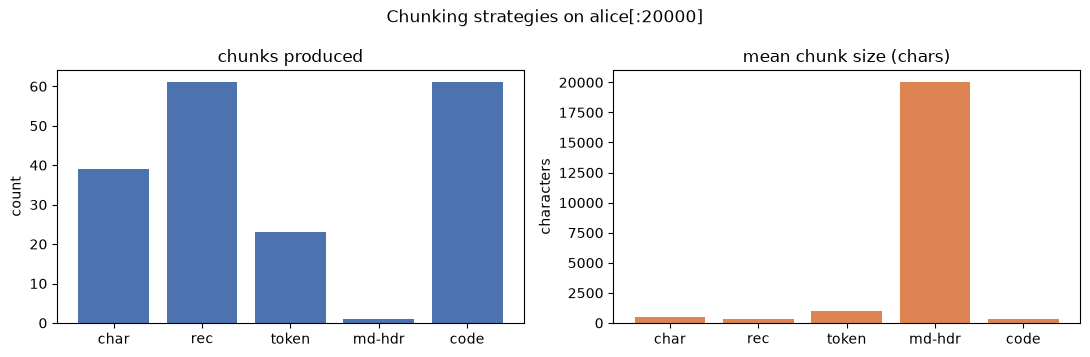

In [3]:
short_labels = ["char", "rec", "token", "md-hdr", "code"]
fig, axes = plt.subplots(1, 2, figsize=(11, 3.6))

axes[0].bar(short_labels, df["n_chunks"], color="#4c72b0")
axes[0].set_title("chunks produced")
axes[0].set_ylabel("count")

axes[1].bar(short_labels, df["mean_chars"], color="#dd8452")
axes[1].set_title("mean chunk size (chars)")
axes[1].set_ylabel("characters")

fig.suptitle("Chunking strategies on alice[:20000]")
plt.tight_layout()
plt.show()

## 4. Reading the scoreboard like a senior tutor

- **markdown-header collapses**: Alice contains no `#` headers, so the
  structural splitter returns essentially ONE giant document - proof that
  tools must MATCH the material, not the fashion.
- **character keeps paragraph purity** but its std/max reveal overshoots;
  recursive enforces the cap with slightly worse boundary stats.
- **token wins arithmetic, loses prose**: exact ~256-token units at the
  highest cut rate - perfect for budgets, brutal for sentences.
- **code-aware on prose** behaves like recursive with python-flavored
  separators: no def edges to find, so it falls back gracefully.

No row is 'the winner'. Each wins a DIFFERENT promise - which is exactly
why the decision guide exists.

In [4]:
decision_guide = pd.DataFrame([
    {"strategy": "character",
     "best_for": "uniformly blank-line-separated prose",
     "watch_out": "no fallback; oversized chunks when separator missing"},
    {"strategy": "recursive",
     "best_for": "general prose RAG (the default)",
     "watch_out": "tighter packing cuts inside paragraphs more often"},
    {"strategy": "token",
     "best_for": "exact LLM context/billing budgets",
     "watch_out": "highest mid-sentence cut rate"},
    {"strategy": "markdown-header",
     "best_for": "docs/wikis/manuals with real headers",
     "watch_out": "no size control; useless without header markup"},
    {"strategy": "code-aware",
     "best_for": "source code (functions stay whole)",
     "watch_out": "huge functions still overflow; wrong language = generic"},
])
print(decision_guide.to_string(index=False))

       strategy                             best_for                                               watch_out
      character uniformly blank-line-separated prose    no fallback; oversized chunks when separator missing
      recursive      general prose RAG (the default)       tighter packing cuts inside paragraphs more often
          token    exact LLM context/billing budgets                           highest mid-sentence cut rate
markdown-header docs/wikis/manuals with real headers          no size control; useless without header markup
     code-aware   source code (functions stay whole) huge functions still overflow; wrong language = generic


## Takeaway

**Match the splitter to the MATERIAL and the BUDGET: recursive for prose,
headers for markdown, languages for code, tokens for hard limits - then
verify with the same three metrics you just learned to read.**

## Summary

- Five strategies, one slice, one pandas scoreboard: n_chunks, mean/std
  chars, and pct_cut_mid_sentence made every trade-off visible.
- The degenerate markdown row (one mega-chunk on prose) was the cheapest
  possible lesson in tool-material matching.
- The bar charts turned numbers into shapes: count versus completeness,
  with the cut-rate column completing the picture.
- This recap mirrors module README's comparison matrix - keep both beside
  you when wiring the capstone's INGEST -> CHUNK stages.